In [1]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
import networkx as nx
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch.utils.data import ConcatDataset
import os
import glob
import torch.nn.functional as F
from torch_geometric.nn import GCNConv as gcn

Welcome to JupyROOT 6.26/16


In [5]:
#This notebook is designed to train and test a very simple GNN that employs graph convolutions. 
#Lets first pull in some of our datasets. We will do 6 files worth to train on, and then 1 to test - to do tmrw, add validation. 
graph_file_directory = '/sdf/data/neutrino/summer25/ktwall/processed/' 
graph_file_paths = glob.glob(os.path.join(graph_file_directory, "*.pt")) 
#Lets just take the first 6 
train_file_paths = graph_file_paths[0:6]
print(train_file_paths)
test_file_paths = graph_file_paths[7]
print(test_file_paths)
valid_file_path = graph_file_paths[8]

['/sdf/data/neutrino/summer25/ktwall/processed/file_2508_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2549_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2507_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2517_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2530_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2522_graphs.pt']
/sdf/data/neutrino/summer25/ktwall/processed/file_2527_graphs.pt


In [6]:
#now lets merge the datasets of our training set.
training_datasets_list = []
for train_path in train_file_paths:
    training_datasets_list.append(torch.load(train_path))
merged_training_dataset = ConcatDataset(training_datasets_list)
testing_dataset = torch.load(test_file_paths)
validation_dataset = torch.load(valid_file_path)

/lscratch/ktwall/tmp/ipykernel_1224086/4071374261.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  training_datasets_list.append(torch.load(train_path))
/lscratch/ktwall/

In [76]:
training_loader = DataLoader(merged_training_dataset, batch_size = 20, drop_last = True, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size = 20, drop_last = True, shuffle=True)
len(training_loader)*training_loader.batch_size #ok so it is like ~1/20th of our full data. 

14720

In [77]:
#now lets copy over our simple network architecture. 
class SimpleGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels1, out_channels1, out_channels2): # we define all of the convolutions and layers here
        super(SimpleGNN, self).__init__()
        self.convolution1 = gcn(in_channels, hidden_channels1) #conv from input dim -> hidden layer dim. Initialization of parameters
        self.convolution2 = gcn(hidden_channels1, out_channels1) #conv from hidden layer dim -> input dim. Initialization of parameters
        self.linear = torch.nn.Linear(out_channels1, out_channels2) #fully connected layer

    def forward(self, x, edge_index): #then apply them in the forward defintion. 
        x = self.convolution1(x, edge_index) #apply first convolution. Here we are actually applying the inputs. 
        x = F.relu(x)
        x = self.convolution2(x, edge_index)
        x = F.relu(x)
        x = self.linear(x)
        return(x) #going to change the model to apply the log softmax at inference. 

In [78]:
import time 
import csv

def run_train(model, loader, validation_dataset_, num_iterations = 100, log_dir = '/sdf/data/neutrino/summer25/ktwall/logs_SimpleGNN', log_prefix= 'slightly_bigger_run', optimizer='SGD', lr=0.001, device = None):
    train_log_name = f'{log_dir}/{log_prefix}train.csv'
    #Lets just use cross entropy
    criterion = torch.nn.CrossEntropyLoss()
    optimizer_fn = getattr(torch.optim,optimizer)
    optimizer = optimizer_fn(model.parameters(), lr=lr)
    # Loop over the entire dataset until the requested number of iterations is reached (pulling this section from Francois guide)
    iteration = 0
    epoch_at_valid = []
    validation_acc = []
    with open(train_log_name, 'w') as csvfile:
        # Initialize CSV writer
        writer = csv.writer(csvfile)
        writer.writerow(['iter', 'epoch', 'loss'])
        while iteration < num_iterations:
            # Loop over data in the loader (one epoch)
            model.train()
            for data in loader:
                #very rudimentary test of accuracy pre any training
                if (iteration == 0):
                    with torch.no_grad():
                        i = 0
                        total_correct = 0
                        for data in validation_dataset_:
                            out = model(data.x, data.edge_index)
                            inference = F.log_softmax(out, dim=1)
                            n_correct = torch.sum(inference.argmax(dim=1) == (data.y))
                            i += len(data.y)
                            total_correct += n_correct
                        print(f"Validation at epoch {iteration/len(loader)}, accuracy = {total_correct/i}") 
                        epoch_at_valid.append(iteration/len(loader))
                        validation_acc.append(total_correct/i)
                x = data.x #input
                y = data.y #labels
                edge_index = data.edge_index #edges

                optimizer.zero_grad()
                loss = criterion( model(x, edge_index), y)
                loss.backward()
                optimizer.step()

                writer.writerow([iteration, iteration/len(loader), loss.item()])
    
                # Increment iteration count, update the progress bar
                iteration += 1
                if iteration % 100 == 0:
                    print(iteration)
                    
                #validation every 500 iterations 
                if iteration % 500 == 0:
                    with torch.no_grad():
                        i = 0
                        total_correct = 0
                        for data in test_loader:
                            out = model(data.x, data.edge_index)
                            inference = F.log_softmax(out, dim=1)
                            n_correct = torch.sum(inference.argmax(dim=1) == (data.y))
                            i += len(data.y)
                            total_correct += n_correct
                        print(f"Validation at epoch {iteration/len(loader)}, accuracy = {total_correct/i}")
                        epoch_at_valid.append(iteration/len(loader))
                        validation_acc.append(total_correct/i)
                        
                    

                # Break if the necessary number of iterations is reached
                if iteration >= num_iterations:
                    break
    return(epoch_at_valid, validation_acc)

In [79]:
SEED = 12345
np.random.seed(SEED)    # Setting the seed for reproducibility
torch.manual_seed(SEED) 
test_SimpleGNN = SimpleGNN(3, 200, 100, 2) #input features, hidden channels, labels
valid_epochs, validation_accuracy = run_train(test_SimpleGNN, training_loader, validation_dataset_ = validation_dataset, num_iterations = 10000, optimizer='Adam')

Validation at epoch 0.0, accuracy = 0.4940018355846405
100
200
300
400
500
Validation at epoch 0.6793478260869565, accuracy = 0.5009765028953552
600
700
800
900
1000
Validation at epoch 1.358695652173913, accuracy = 0.5150272250175476
1100
1200
1300
1400
1500
Validation at epoch 2.0380434782608696, accuracy = 0.5268428921699524
1600
1700
1800
1900
2000
Validation at epoch 2.717391304347826, accuracy = 0.5045678615570068
2100
2200
2300
2400
2500
Validation at epoch 3.3967391304347827, accuracy = 0.5044050812721252
2600
2700
2800
2900
3000
Validation at epoch 4.076086956521739, accuracy = 0.5440943241119385
3100
3200
3300
3400
3500
Validation at epoch 4.755434782608695, accuracy = 0.5070633292198181
3600
3700
3800
3900
4000
Validation at epoch 5.434782608695652, accuracy = 0.5257903933525085
4100
4200
4300
4400
4500
Validation at epoch 6.114130434782608, accuracy = 0.532148540019989
4600
4700
4800
4900
5000
Validation at epoch 6.793478260869565, accuracy = 0.5632771253585815
5100
5200
53

Text(0, 0.5, 'loss')

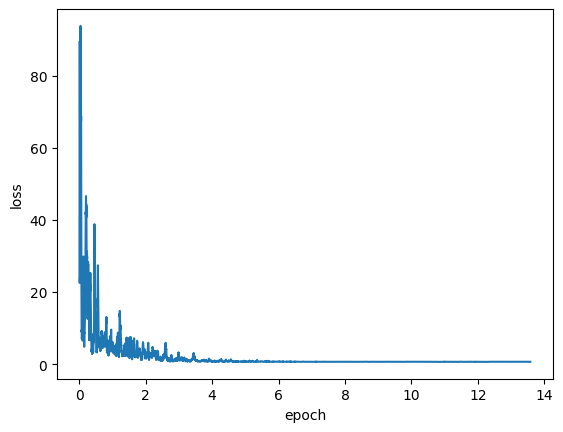

In [80]:
import pandas as pd
df = pd.read_csv('/sdf/data/neutrino/summer25/ktwall/logs_SimpleGNN/slightly_bigger_runtrain.csv')
rolling_ = df.rolling(10).mean()
plt.plot(rolling_['epoch'], rolling_['loss'])
plt.xlabel('epoch')
#plt.yscale('log')
plt.ylabel('loss')
#lmao zero loss surely this means that our model is working perfectly!!!

Text(0, 0.5, 'validation accuracy')

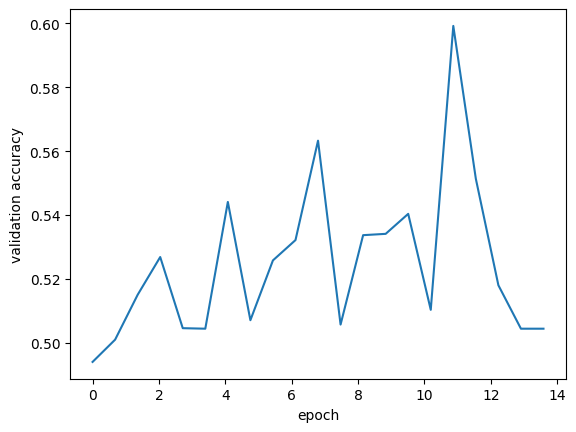

In [81]:
plt.plot(valid_epochs, validation_accuracy)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")

In [64]:
test_loader = DataLoader(testing_dataset, batch_size = 20, drop_last = True)

In [54]:
def run_inference(model, test_loader):
    model.eval()
    with torch.no_grad():
        i = 0
        total_correct = 0
        for data in test_loader:
            out = model(data.x, data.edge_index)
            inference = F.log_softmax(out, dim=1)
            n_correct = torch.sum(inference.argmax(dim=1) == (data.y))
            i += len(data.y)
            total_correct += n_correct
    return(total_correct / i)

In [55]:
"""
# Initialize the output lists
    label_v, softmax_v = [],[]

    # Initialize the softmax function, s_i = exp(-v_i)/(sum_i exp(-v_i))
    softmax   = torch.nn.Softmax(dim=1)

    # Initialize a progress bar
    pbar = tqdm(total=len(loader), position=0, leave=True)

    # Loop over test data, append labels and softmax predictions
    with torch.set_grad_enabled(False):
        for data, label in loader:
            if device:
                data,label = data.to(device), label.to(device)
            label_v.append  ( label.detach().reshape(-1)   )
            softmax_v.append( softmax(model(data)).detach())
            pbar.update(1)
"""

'\n# Initialize the output lists\n    label_v, softmax_v = [],[]\n\n    # Initialize the softmax function, s_i = exp(-v_i)/(sum_i exp(-v_i))\n    softmax   = torch.nn.Softmax(dim=1)\n\n    # Initialize a progress bar\n    pbar = tqdm(total=len(loader), position=0, leave=True)\n\n    # Loop over test data, append labels and softmax predictions\n    with torch.set_grad_enabled(False):\n        for data, label in loader:\n            if device:\n                data,label = data.to(device), label.to(device)\n            label_v.append  ( label.detach().reshape(-1)   )\n            softmax_v.append( softmax(model(data)).detach())\n            pbar.update(1)\n'

In [73]:
run_inference(test_SimpleGNN, test_loader)
#poor guy!

tensor(0.5059)